#### Notebook to analyze videos to find contours across an entire night

In [1]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos

In [ ]:
# ---- Pipeline Configuration ----
# Set all paths and filenames here for easy reuse

# Experiment ID (used in filenames)
exp_id = "041425PA" #Also change date in base_dir below

# Base directories
base_dir = f"/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/{exp_id}_experimental"
results_dir = "../../results/"
scripts_dir = "../../scripts/"

# Video pattern and output files
video_pattern = f"{base_dir}/{exp_id}_experimental_part??.mp4"
output_file = f"{results_dir}contours_{exp_id}_experimental.tab"

# Visualization parameters
black = 110
minArea = 1.5
maxArea = 1000.0
brightnessThreshold = 50
threads = 4
maxy = None

### First find the video and frame number where the lights turn off

In [16]:
# This uses ffmpeg to determine when the lights go off in the video.
#
# black frame is defined by ffmpeg's blackdetect filter with these parameters:
# d=0.5: The minimum duration (in seconds) for a black segment to be detected.
# pix_th=0.10: The pixel threshold; a frame is considered "black" if at least 90% of its pixels have a luma (brightness) value below the default threshold (default is 32 out of 255).
# So, a black frame is one where at least 90% of its pixels are very dark (luma < 32), and a black segment is reported if this condition lasts for at least 0.5 seconds.

import subprocess
import cv2
import re
import pandas as pd
import os

video_path = f"{base_dir}/{exp_id}_experimental_part3.mp4"  # Use global base_dir and exp_id

print("Video path:", video_path)
print("File exists:", os.path.exists(video_path))

# ffmpeg blackdetect
cmd = (
    f'ffmpeg -hide_banner -nostats -i "{video_path}" '
    '-vf "blackdetect=d=0.5:pix_th=0.10" -an -f null - 2>&1 | grep "black_start" | tail -1'
)
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
line = result.stdout.strip()

# Extract blackdetect times
match = re.search(r'black_start:(\d+\.\d+)\s+black_end:(\d+\.\d+)\s+black_duration:(\d+\.?\d*)', line)
if match:
    black_start = float(match.group(1))
    black_end = float(match.group(2))
    black_duration = float(match.group(3))
else:
    black_start = black_end = black_duration = None

# OpenCV video info
cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
total_length = frame_count / fps if fps else None

def sec_to_mmss(seconds):
    if seconds is None:
        return ""
    m, s = divmod(int(seconds), 60)
    return f"{m:02d}:{s:02d}"

def sec_to_frame(seconds, fps):
    if seconds is None or not fps:
        return ""
    return int(round(seconds * fps))

table = [
    {"event": "total_length", "frame": frame_count, "time (mm:ss)": sec_to_mmss(total_length)},
    {"event": "blackstart", "frame": sec_to_frame(black_start, fps), "time (mm:ss)": sec_to_mmss(black_start)},
    {"event": "blackend", "frame": sec_to_frame(black_end, fps), "time (mm:ss)": sec_to_mmss(black_end)},
    {"event": "blackduration", "frame": sec_to_frame(black_duration, fps), "time (mm:ss)": sec_to_mmss(black_duration)},
]

darkness = pd.DataFrame(table)

Video path: /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part3.mp4
File exists: True


In [17]:
print("Video Information")
print(f"FPS: {fps}")
print(f"Video duration (s): {total_length}")
print(darkness)
print("\n")


Video Information
FPS: 10.0
Video duration (s): 2291.8
           event  frame time (mm:ss)
0   total_length  22918        38:11
1     blackstart   7266        12:06
2       blackend  22917        38:11
3  blackduration  15651        26:05




### Here, manually find borders of tanks

Figure(640x480)


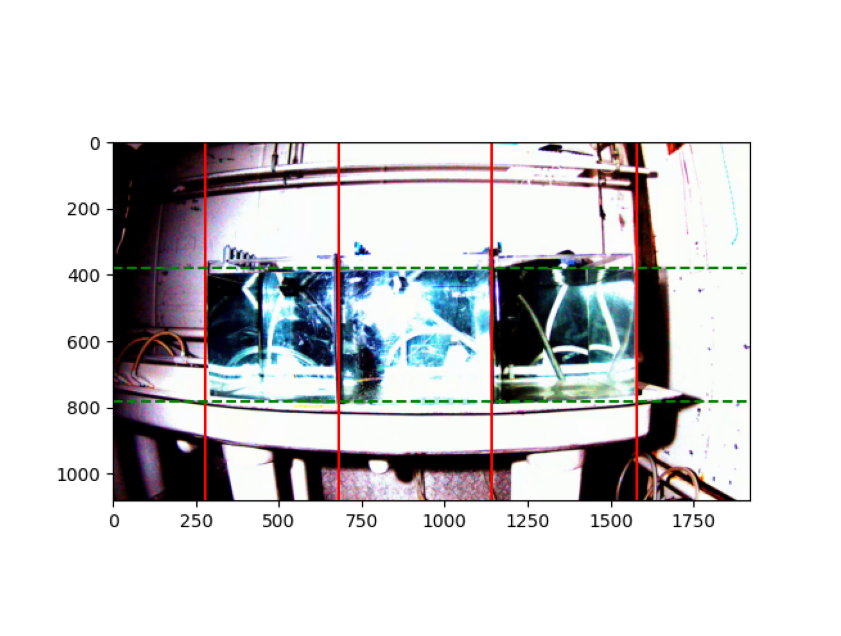

In [4]:
import subprocess
import matplotlib.pyplot as plt
import cv2
import os

# Manually iterate these numbers to identify borders of tanks
x_lines = [280, 680, 1140, 1580]
y_lines = [380, 780]

# Extract xlim and ylim from x_lines and y_lines from manual numbers above
xlim = [x_lines[0], x_lines[-1]]
ylim = [y_lines[0], y_lines[-1]]

# Parameters
video_path = f"{base_dir}/{exp_id}_experimental_part1.mp4"  # Use global base_dir and exp_id
frame_number = 500
output_image = f"{results_dir}{exp_id}_experimental.png"  # Use global results_dir and exp_id

# Build command
cmd = [
    'python3', f'{scripts_dir}visualize_tanx.py',
    '-v', video_path,
    '-f', str(frame_number),
    '-t', *map(str, x_lines),
    '-y', *map(str, y_lines),
    '-o', output_image
]

# Run the script
subprocess.run(cmd, check=True)

# Display the image in the notebook
if os.path.exists(output_image):
    img = cv2.imread(output_image)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print('Visualization image not found.')

In [5]:
# ---- Checks if contours output file already exists and if not runs find_contours.py ----

import os


redo = False  # Set to True to force overwrite

if os.path.exists(output_file) and not redo:
    print(f"Output file '{output_file}' already exists. Skipping contour extraction.")
else:
    print(f"Running contour extraction. Output will be saved to '{output_file}'.")
    results = find_contours_from_videos(
        video_pattern=video_pattern,
        black=black,
        minArea=minArea,
        maxArea=maxArea,
        brightnessThreshold=brightnessThreshold,
        threads=threads,
        outfile=output_file,
        maxy=maxy,
        xlim=xlim,
        ylim=ylim
    )
    print(f'Contour results written to {output_file}')

Running contour extraction. Output will be saved to '../../results/contours_041425PA_control.tab'.


Processing videos:   0%|          | 0/25 [00:00<?, ?it/s]

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_p…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part03.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part03.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part03.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part03.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part03.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part03.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experiment

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_p…

...

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part24.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part24.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part24.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part24.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part24.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part24.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experiment

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_p…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part25.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part25.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part25.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part25.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part25.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part25.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experiment

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_p…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part26.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part26.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part26.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part26.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part26.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experimental_part26.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/14Apr25/041425PA_experimental/041425PA_experiment

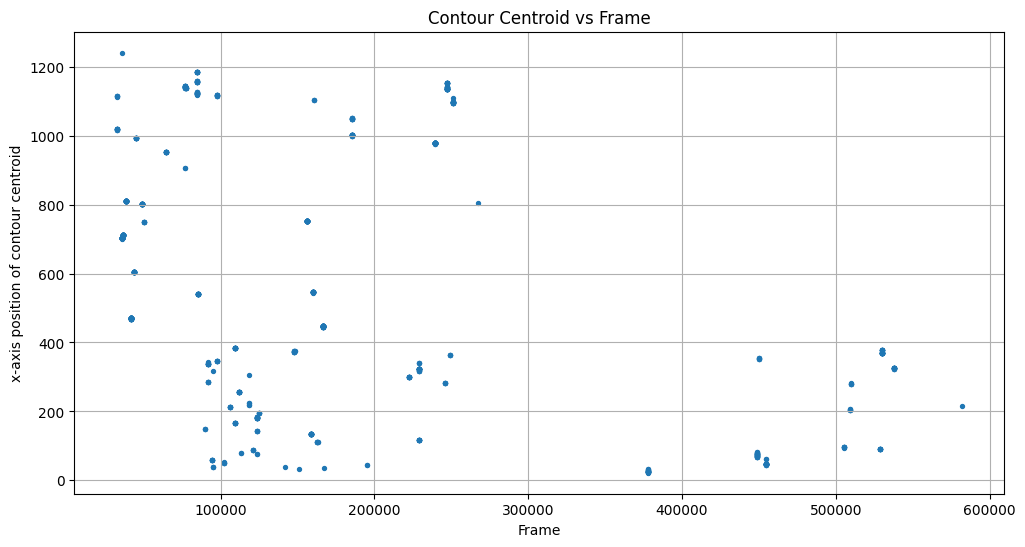

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the tab-separated file
df = pd.read_csv(output_file, sep='\t')

# Plot frame vs cX
plt.figure(figsize=(12, 6))
plt.scatter(df['frame'], df['cX'], s=8)
plt.xlabel('Frame')
plt.ylabel('x-axis position of contour centroid')
plt.title('Contour Centroid vs Frame')
plt.grid(True)
plt.show()